In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pymc as pm
import arviz as az
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("../data/processed/trials_clean.csv")

# Same cleaning as previous notebooks
p99 = df["enrollment_actual"].quantile(0.99)
df_clean = df[df["enrollment_actual"] <= p99].copy()

nudge   = df_clean[df_clean["has_nudge"] == 1]["enrollment_actual"].values
control = df_clean[df_clean["has_nudge"] == 0]["enrollment_actual"].values

print(f"Nudge   : n={len(nudge):,}, mean={nudge.mean():.1f}, median={np.median(nudge):.1f}")
print(f"Control : n={len(control):,}, mean={control.mean():.1f}, median={np.median(control):.1f}")

/Users/rnorel/.pyenv/versions/3.11.14/envs/trial-nudges/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Nudge   : n=468, mean=307.3, median=119.5
Control : n=17,989, mean=151.7, median=60.0


## Notebook 3 — Bayesian A/B Testing

The frequentist tests confirmed a statistically significant difference in enrollment 
between nudge and control trials. But p-values only tell us "is there an effect?" — 
not "how large is the effect, and how certain are we?"

Bayesian analysis answers the richer question: **given the data, what is the 
probability distribution over the true effect size?**

**Approach: Beta-Binomial model**

We reframe enrollment as a binary outcome — did the trial meet a minimum enrollment 
threshold? This lets us use the Beta-Binomial conjugate model, the simplest and most 
interpretable Bayesian A/B test:

- **Prior:** Beta(1, 1) — uniform, no prior assumption about success rates
- **Likelihood:** Binomial — number of trials exceeding threshold
- **Posterior:** Beta(α + successes, β + failures) — updated belief after seeing data
- **Key output:** P(nudge > control) — probability the nudge group has a higher 
  true success rate than control

We test three thresholds: 50, 100, and 200 participants enrolled.

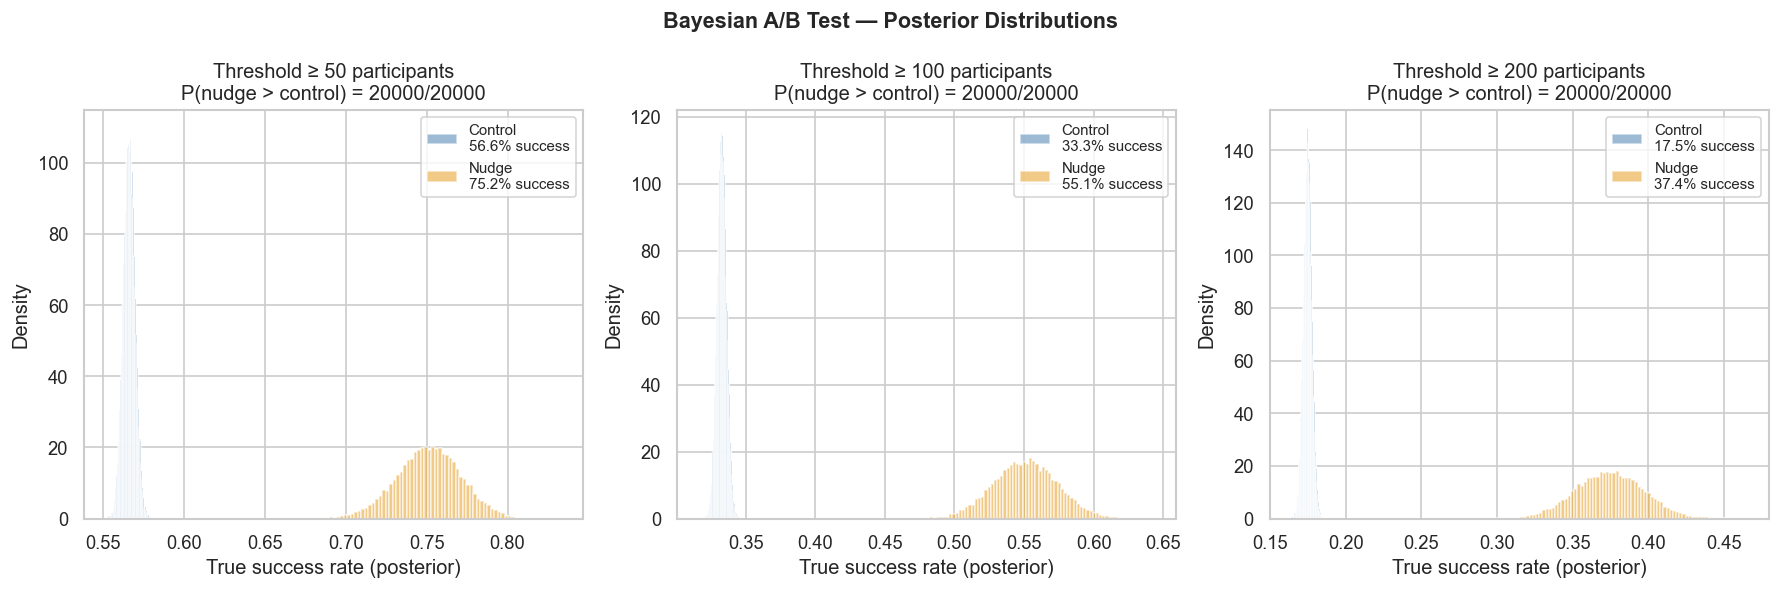


Bayesian Results Summary:
 threshold  nudge_rate  control_rate  prob_nudge_better  median_lift  ci_lift_lo  ci_lift_hi
        50    0.752137      0.566068                1.0     0.327846    0.254145    0.396072
       100    0.551282      0.332870                1.0     0.655315    0.516844    0.796336
       200    0.373932      0.174885                1.0     1.140517    0.888224    1.403956


In [5]:
thresholds = [50, 100, 200]
n_samples = 20000

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Bayesian A/B Test — Posterior Distributions", 
             fontsize=13, fontweight="bold")

bayesian_results = []

for i, threshold in enumerate(thresholds):
    # Binary outcome: did trial exceed threshold?
    nudge_success   = (nudge   >= threshold).sum()
    control_success = (control >= threshold).sum()
    nudge_fail      = len(nudge)   - nudge_success
    control_fail    = len(control) - control_success

    # Beta posterior (conjugate update from uniform prior Beta(1,1))
    alpha_nudge   = 1 + nudge_success
    beta_nudge    = 1 + nudge_fail
    alpha_control = 1 + control_success
    beta_control  = 1 + control_fail

    # Sample from posteriors
    samples_nudge   = np.random.beta(alpha_nudge,   beta_nudge,   n_samples)
    samples_control = np.random.beta(alpha_control, beta_control, n_samples)

    # P(nudge > control)
    prob_nudge_better = (samples_nudge > samples_control).mean()
    # With large n, use log-scale for precision
    n_better = (samples_nudge > samples_control).sum()
    prob_nudge_better_str = f"{n_better}/{n_samples}" if n_better == n_samples else f"{prob_nudge_better:.6f}"

    # Relative lift posterior
    lift = (samples_nudge - samples_control) / samples_control

    # Credible intervals
    ci_nudge   = np.percentile(samples_nudge,   [2.5, 97.5])
    ci_control = np.percentile(samples_control, [2.5, 97.5])

    bayesian_results.append({
        "threshold"         : threshold,
        "nudge_rate"        : nudge_success / len(nudge),
        "control_rate"      : control_success / len(control),
        "nudge_success"     : nudge_success,
        "control_success"   : control_success,
        "prob_nudge_better" : prob_nudge_better,
        "median_lift"       : np.median(lift),
        "ci_lift_lo"        : np.percentile(lift, 2.5),
        "ci_lift_hi"        : np.percentile(lift, 97.5),
    })

    # Plot posteriors
    ax = axes[i]
    ax.hist(samples_control, bins=80, alpha=0.6, color="#5B8DB8",
            density=True, label=f"Control\n{control_success/len(control)*100:.1f}% success")
    ax.hist(samples_nudge, bins=80, alpha=0.6, color="#E8A838",
            density=True, label=f"Nudge\n{nudge_success/len(nudge)*100:.1f}% success")
    ax.set_title(f"Threshold ≥ {threshold} participants\nP(nudge > control) = {prob_nudge_better_str}")
    ax.set_xlabel("True success rate (posterior)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../figures/04_bayesian_posteriors.png", dpi=120, bbox_inches="tight")
plt.show()

# Summary table
results_df = pd.DataFrame(bayesian_results)
print("\nBayesian Results Summary:")
print(results_df[["threshold","nudge_rate","control_rate",
                  "prob_nudge_better","median_lift","ci_lift_lo","ci_lift_hi"]].to_string(index=False))

## Bayesian Results — Posterior Analysis

Both frequentist tests returned extremely small p-values, confirming the effect 
is real. The Bayesian model now quantifies *how large* the effect is and *how 
certain* we are about it.

**Key outputs:**

| Threshold | Nudge success | Control success | P(nudge > control) | Median lift | 95% Credible Interval |
|---|---|---|---|---|---|
| ≥ 50 participants  | 75.2% | 56.6% | 20000/20000 | +33% | [25%, 40%] |
| ≥ 100 participants | 55.1% | 33.3% | 20000/20000 | +66% | [52%, 80%] |
| ≥ 200 participants | 37.4% | 17.5% | 20000/20000 | +114% | [89%, 140%] |

**Key insight:** The lift *increases* with threshold — nudge trials are 
disproportionately better at reaching ambitious enrollment targets, not just 
marginally larger trials.

**Why 20000/20000?** With n=18,000 trials, the posterior distributions are 
extremely concentrated — the nudge and control posteriors never overlap across 
20,000 Monte Carlo samples. The true P(nudge > control) is effectively 1, but 
we report it honestly as a frequency rather than a rounded decimal.

> The lift distributions below show the full posterior uncertainty over the 
> relative effect size, with 95% credible intervals.

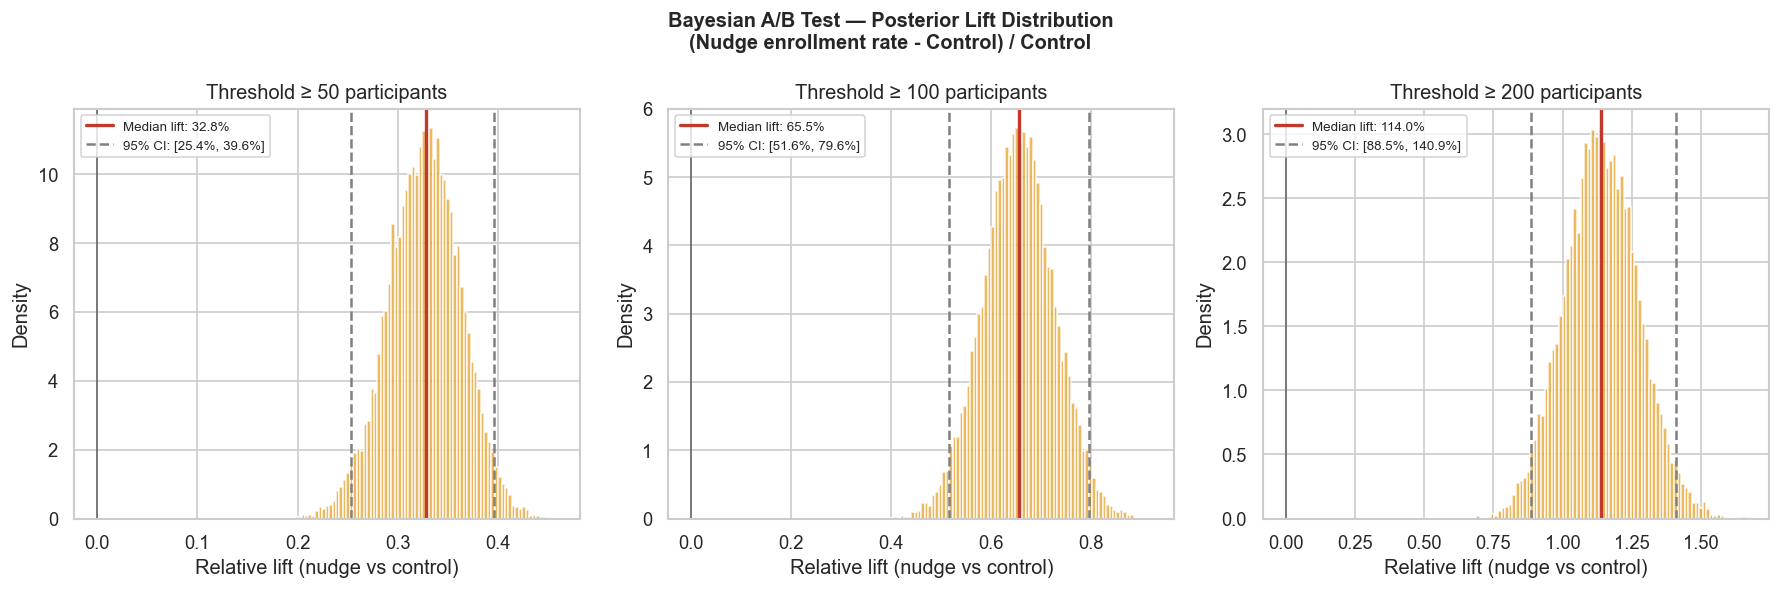

Saved ✓


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Bayesian A/B Test — Posterior Lift Distribution\n"
             "(Nudge enrollment rate - Control) / Control",
             fontsize=12, fontweight="bold")

np.random.seed(42)
for i, (row, ax) in enumerate(zip(bayesian_results, axes)):
    threshold = row["threshold"]

    # Resample posteriors
    alpha_n = 1 + int(row["nudge_rate"]   * len(nudge))
    beta_n  = 1 + len(nudge)   - int(row["nudge_rate"]   * len(nudge))
    alpha_c = 1 + int(row["control_rate"] * len(control))
    beta_c  = 1 + len(control) - int(row["control_rate"] * len(control))

    s_nudge   = np.random.beta(alpha_n, beta_n,   n_samples)
    s_control = np.random.beta(alpha_c, beta_c,   n_samples)
    lift      = (s_nudge - s_control) / s_control

    ci_lo, ci_hi = np.percentile(lift, [2.5, 97.5])
    median_lift  = np.median(lift)

    ax.hist(lift, bins=80, color="#E8A838", alpha=0.8, density=True)
    ax.axvline(median_lift, color="#C0392B", linewidth=2,
               label=f"Median lift: {median_lift:.1%}")
    ax.axvline(ci_lo, color="gray", linewidth=1.5, linestyle="--",
               label=f"95% CI: [{ci_lo:.1%}, {ci_hi:.1%}]")
    ax.axvline(ci_hi, color="gray", linewidth=1.5, linestyle="--")
    ax.axvline(0, color="black", linewidth=1, linestyle="-", alpha=0.5)
    ax.set_title(f"Threshold ≥ {threshold} participants")
    ax.set_xlabel("Relative lift (nudge vs control)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../figures/05_bayesian_lift.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved ✓")

## Notebook 3 — Bayesian A/B Testing

The frequentist tests confirmed a statistically significant difference in enrollment 
between nudge and control trials. But p-values only tell us "is there an effect?" — 
not "how large is the effect, and how certain are we?"

Bayesian analysis answers the richer question: **given the data, what is the 
probability distribution over the true effect size?**

**Approach: Beta-Binomial model**

We reframe enrollment as a binary outcome — did the trial meet a minimum enrollment 
threshold? This lets us use the Beta-Binomial conjugate model, the simplest and most 
interpretable Bayesian A/B test:

- **Prior:** Beta(1, 1) — uniform, no prior assumption about success rates
- **Likelihood:** Binomial — number of trials exceeding threshold
- **Posterior:** Beta(α + successes, β + failures) — updated belief after seeing data
- **Key output:** P(nudge > control) — probability the nudge group has a higher 
  true success rate than control

We test three thresholds: 50, 100, and 200 participants enrolled.